## **Importing Neccessary Libraries**

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

## **Importing Datasets**

In [63]:
df = pd.read_csv(r"D:\Machine_learning\Datasets\non-linear data.csv")
df

,x,y
0,0.00000,-0.155043
1,0.02004,0.081809
2,0.04008,-0.014298
3,0.06012,0.143978
4,0.08016,0.019553
...,...,...
495,9.91984,-0.959196
496,9.93988,-0.912081
497,9.95992,-1.026475
498,9.97996,-1.019379


## **Visualizing The Dataset**

Text(0, 0.5, 'values of Y')

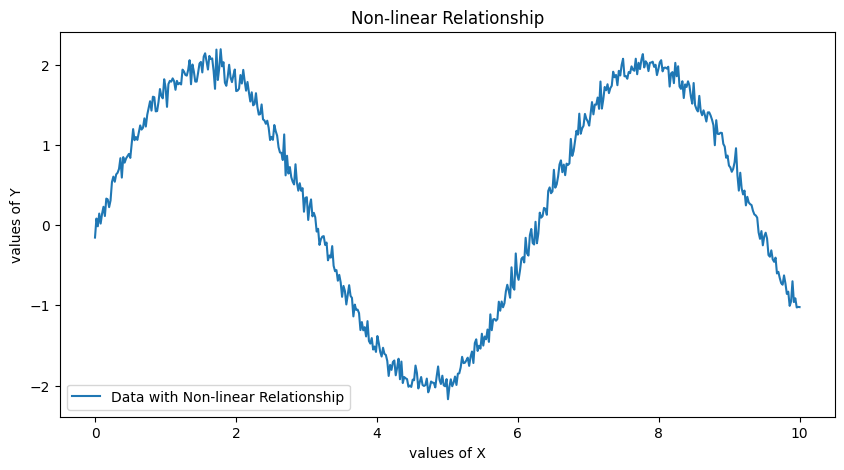

In [64]:

plt.figure(figsize=(10, 5))
plt.plot(df['x'],df['y'], label = "Data with Non-linear Relationship")
plt.legend()
plt.title('Non-linear Relationship')
plt.xlabel("values of X")
plt.ylabel("values of Y")


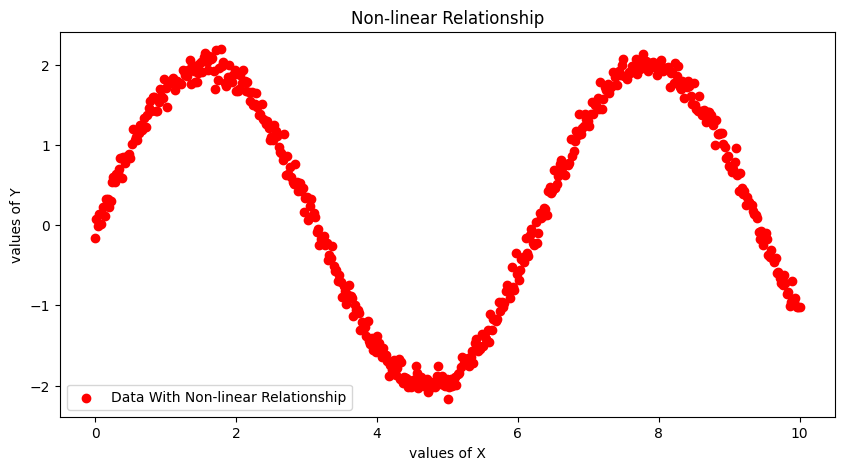

In [65]:
plt.figure(figsize=(10, 5))
plt.scatter(df['x'],df['y'], color = "Red", label = "Data With Non-linear Relationship")
plt.xlabel("values of X")
plt.ylabel("values of Y")
plt.title('Non-linear Relationship')
plt.legend()

## **Cheking Correlation Between**

In [66]:
df.corr()

,x,y
x,1.000000,-0.065736
y,-0.065736,1.000000


## **Fitting Model**

In [67]:
X = df[['x']]
y = df[['y']]

In [68]:
model  = LinearRegression()
polyreg = PolynomialFeatures(degree = 6)

X_poly = polyreg.fit_transform(X)



In [69]:
X_poly.shape

(500, 7)

In [70]:
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 7)","[[ 0. , 1.44, 1.17,..., 0.32,-0.03, 0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.04]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[5375864.18, 48046.97, 1142.71,..., 6.06, 0.87, 0. ]"


In [71]:
model.score(X_poly, y)

0.9930285943311639

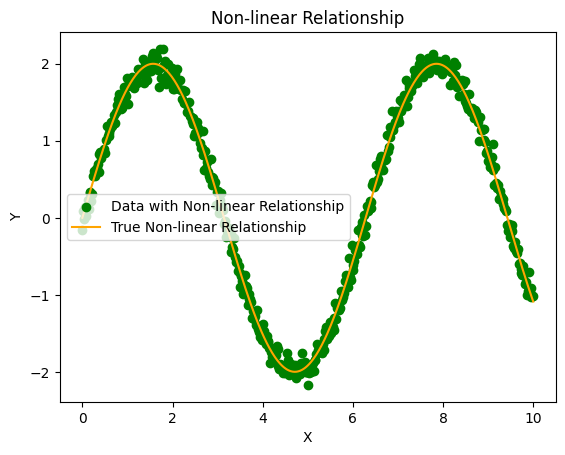

In [72]:
plt.scatter(X, y, color='green', label='Data with Non-linear Relationship')
plt.plot(X, 2 * np.sin(X), color='orange', label='True Non-linear Relationship')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Non-linear Relationship')
plt.legend()

In [73]:
df['predicted_y'] = model.predict(X_poly)
df

,x,y,predicted_y
0,0.00000,-0.155043,0.038719
1,0.02004,0.081809,0.067985
2,0.04008,-0.014298,0.098131
3,0.06012,0.143978,0.129099
4,0.08016,0.019553,0.160833
...,...,...,...
495,9.91984,-0.959196,-0.793587
496,9.93988,-0.912081,-0.797653
497,9.95992,-1.026475,-0.799271
498,9.97996,-1.019379,-0.798349


## **Separate Test**

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y , test_size = .20, random_state = 69)

In [75]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 7)","[[ 0. , 1.4 , 1.21,..., 0.32,-0.03, 0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.05]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[4777060.12, 43299.67, 1020.5 ,..., 4.99, 0.66, 0. ]"


## **Training Score**

In [76]:
reg.score(X_train, y_train)

0.9936387244030379

## **Testing Score**

In [77]:
reg.score(X_test, y_test)

0.9898112253567322